<a href="https://colab.research.google.com/github/saniya-ahuja/dog-vs-cat-classifier/blob/main/Cats_vs_Dogs_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle

In [13]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [14]:
!kaggle competitions download -c dogs-vs-cats

100% 812M/812M [00:05<00:00, 145MB/s]



In [17]:
!unzip dogs-vs-cats.zip

Archive:  dogs-vs-cats.zip
  inflating: sampleSubmission.csv    
  inflating: test1.zip               
  inflating: train.zip               


In [18]:
!unzip train.zip
!unzip test1.zip

Streaming output truncated to the last 5000 lines.
  inflating: test1/5499.jpg          
  inflating: test1/55.jpg            
  inflating: test1/550.jpg           
  inflating: test1/5500.jpg          
  inflating: test1/5501.jpg          
  inflating: test1/5502.jpg          
  inflating: test1/5503.jpg          
  inflating: test1/5504.jpg          
  inflating: test1/5505.jpg          
  inflating: test1/5506.jpg          
  inflating: test1/5507.jpg          
  inflating: test1/5508.jpg          
  inflating: test1/5509.jpg          
  inflating: test1/551.jpg           
  inflating: test1/5510.jpg          
  inflating: test1/5511.jpg          
  inflating: test1/5512.jpg          
  inflating: test1/5513.jpg          
  inflating: test1/5514.jpg          
  inflating: test1/5515.jpg          
  inflating: test1/5516.jpg          
  inflating: test1/5517.jpg          
  inflating: test1/5518.jpg          
  inflating: test1/5519.jpg          
  inflating: test1/552.jpg           

In [19]:
import os
path, dirs, files = next(os.walk("/content/train"))
file_count = len(files)
print(file_count)

25000


In [20]:
file_names = os.listdir('/content/train')
print(file_names)

['dog.4708.jpg', 'dog.11061.jpg', 'dog.10984.jpg', 'dog.2742.jpg', 'dog.9525.jpg', 'cat.10772.jpg', 'dog.4460.jpg', 'cat.5592.jpg', 'cat.8858.jpg', 'dog.5734.jpg', 'cat.7714.jpg', 'cat.3887.jpg', 'dog.5666.jpg', 'dog.4419.jpg', 'dog.4255.jpg', 'cat.8546.jpg', 'dog.4995.jpg', 'dog.3264.jpg', 'dog.9038.jpg', 'dog.12496.jpg', 'dog.9725.jpg', 'dog.2511.jpg', 'cat.6759.jpg', 'cat.9752.jpg', 'dog.6184.jpg', 'dog.9386.jpg', 'cat.11638.jpg', 'dog.8148.jpg', 'cat.1512.jpg', 'cat.9949.jpg', 'cat.4080.jpg', 'cat.4081.jpg', 'cat.1608.jpg', 'dog.9135.jpg', 'dog.10086.jpg', 'dog.3130.jpg', 'dog.11696.jpg', 'cat.4546.jpg', 'dog.9917.jpg', 'cat.4502.jpg', 'dog.3486.jpg', 'dog.5541.jpg', 'cat.735.jpg', 'dog.4799.jpg', 'dog.9308.jpg', 'cat.933.jpg', 'cat.11078.jpg', 'dog.11264.jpg', 'dog.10241.jpg', 'cat.567.jpg', 'cat.5737.jpg', 'cat.7382.jpg', 'dog.8189.jpg', 'dog.3221.jpg', 'cat.2771.jpg', 'cat.10839.jpg', 'cat.1817.jpg', 'dog.8657.jpg', 'cat.7219.jpg', 'dog.280.jpg', 'dog.4638.jpg', 'cat.5174.jpg', 

In [21]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from google.colab.patches import cv2_imshow

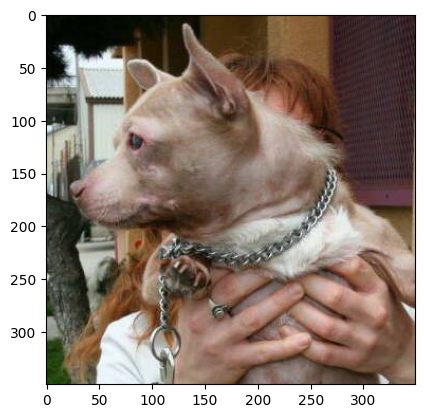

In [22]:
img = mpimg.imread('/content/train/dog.2742.jpg')
imgplot = plt.imshow(img)
plt.show()

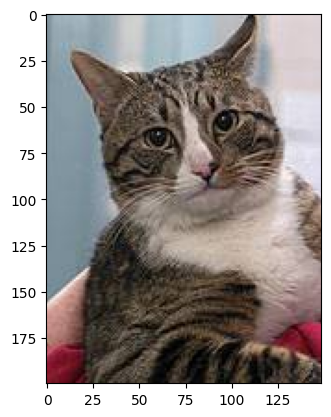

In [23]:
img = mpimg.imread('/content/train/cat.10772.jpg')
imgplot = plt.imshow(img)
plt.show()

In [24]:
file_names = os.listdir('/content/train')

for i in range(10):
  name = file_names[i]
  print(name[0:3])

dog
dog
dog
dog
dog
cat
dog
cat
cat
dog


In [25]:
file_names = os.listdir('/content/train/')

dog_count = 0
cat_count = 0

for img_file in file_names:

  name = img_file[0:3]

  if name == 'dog':
    dog_count += 1

  else:
    cat_count += 1

print('Number of dog images =', dog_count)
print('Number of cat images =', cat_count)

Number of dog images = 12500
Number of cat images = 12500


In [26]:
os.mkdir('/content/image resized')

In [27]:
original_folder = '/content/train/'
resized_folder = '/content/image resized/'

for i in range(2000):

  filename = os.listdir(original_folder)[i]
  img_path = original_folder+filename

  img = Image.open(img_path)
  img = img.resize((224, 224))
  img = img.convert('RGB')

  newImgPath = resized_folder+filename
  img.save(newImgPath)

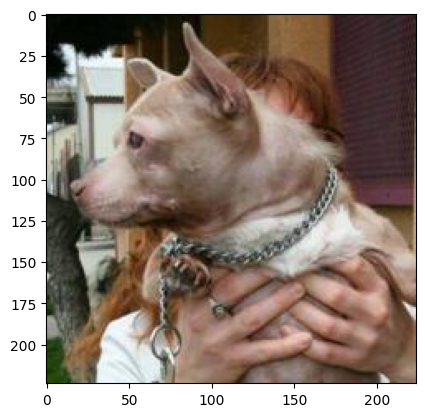

In [28]:
# display resized dog image
img = mpimg.imread('/content/image resized/dog.2742.jpg')
imgplt = plt.imshow(img)
plt.show()

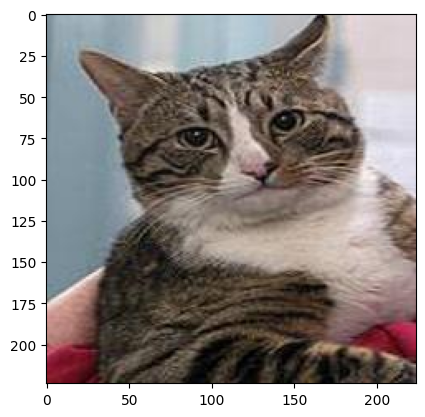

In [29]:
# display resized cat image
img = mpimg.imread('/content/image resized/cat.10772.jpg')
imgplt = plt.imshow(img)
plt.show()

**Creating labels for resized images of dogs and cats**


Cat --> 0
Dog --> 1

In [32]:
# creaing a for loop to assign labels
filenames = os.listdir('/content/image resized/')


labels = []

for i in range(2000):

  file_name = filenames[i]
  label = file_name[0:3]

  if label == 'dog':
    labels.append(1)

  else:
    labels.append(0)

In [31]:
print(filenames[0:5])
print(len(filenames))

['dog.4708.jpg', 'dog.11061.jpg', 'dog.10984.jpg', 'dog.2742.jpg', 'dog.9525.jpg']
2000


In [33]:
# counting the images of dogs and cats out of 2000 images
values, counts = np.unique(labels, return_counts=True)
print(values)
print(counts)

[0 1]
[ 983 1017]


Converting all the resized images to numpy arrays


In [34]:
import cv2
import glob

In [35]:
image_directory = '/content/image resized/'
image_extension = ['png', 'jpg']

files = []

[files.extend(glob.glob(image_directory + '*.' + e)) for e in image_extension]

dog_cat_images = np.asarray([cv2.imread(file) for file in files])

In [36]:
print(dog_cat_images)

[[[[114 123 110]
   [114 123 110]
   [114 123 110]
   ...
   [ 99 108  95]
   [100 109  96]
   [101 110  97]]

  [[111 120 107]
   [111 120 107]
   [112 121 108]
   ...
   [100 109  96]
   [101 110  97]
   [101 110  97]]

  [[108 118 102]
   [108 118 102]
   [109 119 103]
   ...
   [101 111  95]
   [102 112  96]
   [102 112  96]]

  ...

  [[166 175 142]
   [166 175 142]
   [166 175 142]
   ...
   [ 86  88  88]
   [ 77  79  79]
   [ 79  81  81]]

  [[166 175 142]
   [166 175 142]
   [166 175 142]
   ...
   [ 98 100 100]
   [ 89  91  91]
   [ 86  88  88]]

  [[166 175 142]
   [166 175 142]
   [166 175 142]
   ...
   [109 111 111]
   [106 108 108]
   [ 97  99  99]]]


 [[[160 158 157]
   [159 157 156]
   [160 158 157]
   ...
   [156 156 156]
   [158 158 158]
   [159 159 159]]

  [[166 164 163]
   [165 163 162]
   [164 162 161]
   ...
   [158 158 158]
   [159 159 159]
   [160 160 160]]

  [[171 169 168]
   [169 167 166]
   [167 165 164]
   ...
   [160 160 160]
   [161 161 161]
   [162 162

In [37]:
type(dog_cat_images)

numpy.ndarray

In [38]:
print(dog_cat_images.shape)

(2000, 224, 224, 3)


In [39]:
X = dog_cat_images
Y = np.asarray(labels)

**Train Test Split**

In [40]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [41]:
print(X.shape, X_train.shape, X_test.shape)

(2000, 224, 224, 3) (1600, 224, 224, 3) (400, 224, 224, 3)


1600 --> training images

400 --> test images

In [42]:
# scaling the data
X_train_scaled = X_train/255

X_test_scaled = X_test/255

In [43]:
print(X_train_scaled)

[[[[0.7254902  0.67843137 0.67058824]
   [0.7254902  0.67843137 0.67058824]
   [0.7254902  0.67843137 0.67058824]
   ...
   [0.30588235 0.29803922 0.29411765]
   [0.28627451 0.29019608 0.28235294]
   [0.39215686 0.39607843 0.38823529]]

  [[0.67843137 0.63137255 0.62352941]
   [0.67843137 0.63137255 0.62352941]
   [0.67843137 0.63137255 0.62352941]
   ...
   [0.2        0.19215686 0.18823529]
   [0.18039216 0.18431373 0.17647059]
   [0.28235294 0.28627451 0.27843137]]

  [[0.67058824 0.62352941 0.61568627]
   [0.67058824 0.62352941 0.61568627]
   [0.67058824 0.62352941 0.61568627]
   ...
   [0.21960784 0.21176471 0.20784314]
   [0.19215686 0.19607843 0.18823529]
   [0.28627451 0.29019608 0.28235294]]

  ...

  [[0.31372549 0.34901961 0.40392157]
   [0.3254902  0.36078431 0.41568627]
   [0.3254902  0.36078431 0.41568627]
   ...
   [0.18823529 0.24705882 0.28235294]
   [0.2        0.26666667 0.30196078]
   [0.29411765 0.36078431 0.39607843]]

  [[0.30196078 0.33333333 0.38431373]
   [0.3

**Building the Neural Network**

In [44]:
import tensorflow as tf
import tensorflow_hub as hub

In [50]:
mobilenet_model = 'https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4'

pretrained_model = hub.KerasLayer(mobilenet_model, input_shape=(224,224,3), trainable=False)

In [ ]:
num_of_classes = 2

model = tf.keras.Sequential([

    pretrained_model,
    tf.keras.layers.Dense(num_of_classes)

])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 1280)              2257984   
                                                                 
 dense (Dense)               (None, 2)                 2562      
                                                                 
Total params: 2,260,546
Trainable params: 2,562
Non-trainable params: 2,257,984
_________________________________________________________________


In [ ]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ['acc']
)

In [ ]:
model.fit(X_train_scaled, Y_train, epochs=5)

Epoch 1/5
50/50 [==============================] - 47s 861ms/step - loss: 0.2163 - acc: 0.9162
Epoch 2/5
50/50 [==============================] - 42s 838ms/step - loss: 0.0746 - acc: 0.9756
Epoch 3/5
50/50 [==============================] - 44s 872ms/step - loss: 0.0552 - acc: 0.9825
Epoch 4/5
50/50 [==============================] - 41s 824ms/step - loss: 0.0417 - acc: 0.9894
Epoch 5/5
50/50 [==============================] - 41s 825ms/step - loss: 0.0345 - acc: 0.9937


In [ ]:
score, acc = model.evaluate(X_test_scaled, Y_test)
print('Test Loss =', score)
print('Test Accuracy =', acc)

13/13 [==============================] - 12s 866ms/step - loss: 0.0812 - acc: 0.9775
Test Loss = 0.0812455490231514
Test Accuracy = 0.9775000214576721


**Predictive System**

Path of the image to be predicted: /content/dog.jpg


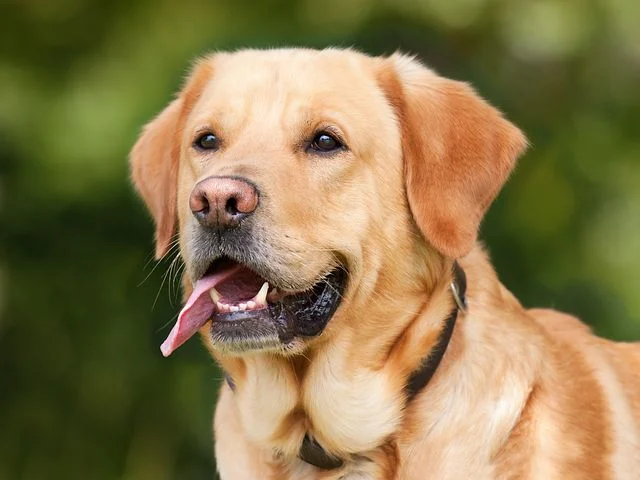

[[-4.6012597  3.784018 ]]
1
The image represents a Dog


In [ ]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resize = cv2.resize(input_image, (224,224))

input_image_scaled = input_image_resize/255

image_reshaped = np.reshape(input_image_scaled, [1,224,224,3])

input_prediction = model.predict(image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 0:
  print('The image represents a Cat')

else:
  print('The image represents a Dog')

Path of the image to be predicted: /content/cat.jpg


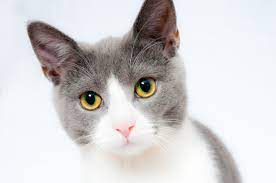

[[ 4.302739 -4.893738]]
0
The image represents a Cat


In [ ]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resize = cv2.resize(input_image, (224,224))

input_image_scaled = input_image_resize/255

image_reshaped = np.reshape(input_image_scaled, [1,224,224,3])

input_prediction = model.predict(image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 0:
  print('The image represents a Cat')

else:
  print('The image represents a Dog')